# Project Clustering Analysis

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

### Data For Clustering

In [7]:
data = pd.read_csv('clustering_data.csv')
data.dtypes

GCIF                           object
Area                           object
Jalur_Pembukaan                object
Vintage                        object
Usia                          float64
Jenis_Kelamin                  object
Status_Perkawinan              object
Jumlah_Anak                     int64
Pendidikan                     object
Produk_Tabungan                 int64
Produk_Deposito                 int64
Produk_Kartu_Kredit             int64
Produk_Kredit_Rumah             int64
Produk_Kredit_Kendaraan         int64
Produk_Kredit_Dana_Tunai        int64
Total_Kepemilikan_Produk        int64
Pendapatan_Tahunan              int64
Total_Relationship_Balance      int64
dtype: object

In [8]:
data

,GCIF,Area,Jalur_Pembukaan,Vintage,Usia,Jenis_Kelamin,Status_Perkawinan,Jumlah_Anak,Pendidikan,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,G28036,Bogor,Internet Banking,< 1 Tahun,69.0,Laki-laki,Menikah,3,Doktor,1,0,0,0,0,0,1,747,44607
1,G18528,Jakarta,Telemarketing,< 1 Tahun,23.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,198,10668586
2,G22419,Surabaya,Telemarketing,< 1 Tahun,30.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,280,299076075
3,G04482,Bandung,Cabang,< 1 Tahun,45.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,431,417250579
4,G07807,Bandung,Aplikasi Digital,< 1 Tahun,34.0,Perempuan,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,184,453573593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28124,G14522,Solo,Cabang,2 - 3 Tahun,47.0,Perempuan,Menikah,0,Tidak Sekolah Formal,1,1,1,1,1,1,6,364,600734753
28125,G15052,Bandung,Telemarketing,2 - 3 Tahun,38.0,Perempuan,Menikah,0,Tidak Sekolah Formal,1,1,1,1,1,1,6,350,764670896
28126,G06299,Jogja,Internet Banking,2 - 3 Tahun,58.0,Laki-laki,Cerai,4,Tidak Sekolah Formal,1,1,1,1,1,1,6,365,629634394
28127,G17962,Jakarta,Telemarketing,2 - 3 Tahun,NaN,Perempuan,Janda/Duda,1,Tidak Sekolah Formal,1,1,1,1,1,1,6,225,423564729


### Data Understanding

In [18]:
data.groupby(('Area'))['Area'].count()

Area
Bandung     5813
Bogor       1001
Jakarta     5893
Jogja       2532
Solo        4236
Surabaya    4229
Name: Area, dtype: int64

In [31]:
data.groupby(('Area')).mean(numeric_only=True).astype(int)

,Usia,Jumlah_Anak,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
Area,,,,,,,,,,,
Bandung,42,1,0,0,0,0,0,0,3,425,237554163
Bogor,42,1,0,0,0,0,0,0,3,424,237145385
Jakarta,42,1,0,0,0,0,0,0,3,426,240392357
Jogja,42,1,0,0,0,0,0,0,3,423,240937554
Solo,42,1,0,0,0,0,0,0,3,426,243320609
Surabaya,42,1,0,0,0,0,0,0,3,428,243198432


In [21]:
data.groupby(('Vintage'))['Vintage'].count()

Vintage
2 - 3 Tahun    11776
< 1 Tahun       7126
> 4 Tahun       4802
Name: Vintage, dtype: int64

In [32]:
data.groupby(('Vintage')).mean(numeric_only=True).astype(int)

,Usia,Jumlah_Anak,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
Vintage,,,,,,,,,,,
2 - 3 Tahun,42,1,0,0,0,0,0,0,3,427,241157688
< 1 Tahun,42,1,0,0,0,0,0,0,3,426,240654491
> 4 Tahun,42,1,0,0,0,0,0,0,3,422,239355761


In [23]:
data.groupby(('Jalur_Pembukaan'))['Jalur_Pembukaan'].count()

Jalur_Pembukaan
Aplikasi Digital    5208
Cabang              4974
Internet Banking    4869
Telemarketing       8653
Name: Jalur_Pembukaan, dtype: int64

In [33]:
data.groupby(('Jalur_Pembukaan')).mean(numeric_only=True).astype(int)

,Usia,Jumlah_Anak,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
Jalur_Pembukaan,,,,,,,,,,,
Aplikasi Digital,42,1,0,0,0,0,0,0,3,425,241837115
Cabang,42,1,0,0,0,0,0,0,3,430,238309803
Internet Banking,42,1,0,0,0,0,0,0,3,426,242150062
Telemarketing,42,1,0,0,0,0,0,0,3,424,240413023


In [25]:
data.groupby(('Status_Perkawinan'))['Status_Perkawinan'].count()

Status_Perkawinan
Belum Menikah     8083
Cerai             4036
Menikah          11585
Name: Status_Perkawinan, dtype: int64

In [34]:
data.groupby(('Status_Perkawinan')).mean(numeric_only=True).astype(int)

,Usia,Jumlah_Anak,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
Status_Perkawinan,,,,,,,,,,,
Belum Menikah,39,0,1,0,0,0,0,0,2,420,236634673
Cerai,50,1,1,0,0,0,0,0,2,426,233783403
Menikah,42,1,0,0,0,0,0,0,3,430,245826096


### Data Preparation

Pengecekan data duplikasi dan missing data

In [12]:
data.isnull().sum()

GCIF                             0
Area                             0
Jalur_Pembukaan                  0
Vintage                          0
Usia                          4045
Jenis_Kelamin                    0
Status_Perkawinan                0
Jumlah_Anak                      0
Pendidikan                       0
Produk_Tabungan                  0
Produk_Deposito                  0
Produk_Kartu_Kredit              0
Produk_Kredit_Rumah              0
Produk_Kredit_Kendaraan          0
Produk_Kredit_Dana_Tunai         0
Total_Kepemilikan_Produk         0
Pendapatan_Tahunan               0
Total_Relationship_Balance       0
dtype: int64

In [13]:
data = data.dropna()
data.isnull().sum()

GCIF                          0
Area                          0
Jalur_Pembukaan               0
Vintage                       0
Usia                          0
Jenis_Kelamin                 0
Status_Perkawinan             0
Jumlah_Anak                   0
Pendidikan                    0
Produk_Tabungan               0
Produk_Deposito               0
Produk_Kartu_Kredit           0
Produk_Kredit_Rumah           0
Produk_Kredit_Kendaraan       0
Produk_Kredit_Dana_Tunai      0
Total_Kepemilikan_Produk      0
Pendapatan_Tahunan            0
Total_Relationship_Balance    0
dtype: int64

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.count()

GCIF                          24084
Area                          24084
Jalur_Pembukaan               24084
Vintage                       24084
Usia                          24084
Jenis_Kelamin                 24084
Status_Perkawinan             24084
Jumlah_Anak                   24084
Pendidikan                    24084
Produk_Tabungan               24084
Produk_Deposito               24084
Produk_Kartu_Kredit           24084
Produk_Kredit_Rumah           24084
Produk_Kredit_Kendaraan       24084
Produk_Kredit_Dana_Tunai      24084
Total_Kepemilikan_Produk      24084
Pendapatan_Tahunan            24084
Total_Relationship_Balance    24084
dtype: int64

In [16]:
#Mendeteksi dan mengatasi outlier (misal dibagi dengan Z-score)
from scipy import stats
z_scores =stats.zscore(data[['Usia', 'Pendapatan_Tahunan', 'Total_Relationship_Balance']])
data = data[(z_scores < 3).all(axis=1)] #menghapus z-score > 3

In [17]:
data.count()

GCIF                          23704
Area                          23704
Jalur_Pembukaan               23704
Vintage                       23704
Usia                          23704
Jenis_Kelamin                 23704
Status_Perkawinan             23704
Jumlah_Anak                   23704
Pendidikan                    23704
Produk_Tabungan               23704
Produk_Deposito               23704
Produk_Kartu_Kredit           23704
Produk_Kredit_Rumah           23704
Produk_Kredit_Kendaraan       23704
Produk_Kredit_Dana_Tunai      23704
Total_Kepemilikan_Produk      23704
Pendapatan_Tahunan            23704
Total_Relationship_Balance    23704
dtype: int64

### Filtering Data Telemarketing Only

In [35]:
data0 = data[data['Jalur_Pembukaan']=='Telemarketing']

In [37]:
data0 = data0.drop(columns=['GCIF', 'Jalur_Pembukaan']).reset_index(drop=True)
data0 = data0.reset_index()
data0.head()

,index,Area,Vintage,Usia,Jenis_Kelamin,Status_Perkawinan,Jumlah_Anak,Pendidikan,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,0,Jakarta,< 1 Tahun,23.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,198,10668586
1,1,Surabaya,< 1 Tahun,30.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,280,299076075
2,2,Solo,< 1 Tahun,29.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,295,76653088
3,3,Jakarta,< 1 Tahun,49.0,Laki-laki,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,443,247157199
4,4,Jakarta,< 1 Tahun,21.0,Perempuan,Belum Menikah,0,Doktor,1,0,0,0,0,0,1,257,27585562


### Pembagian Dataset Experiment

1. Experiment 0 : semua variabel digunakan
2. Experiment 1 : menggunakan demographics
3. Experiment 2 : menggunakan financial related value

In [38]:
data1 = data0.iloc[:, 1:8]

In [39]:
data2 = data0.iloc[:, 8:17]

### Melakukan encoding data category

In [40]:
data1 = pd.get_dummies(data1, columns=['Area', 'Jenis_Kelamin', 'Status_Perkawinan', 'Pendidikan', 'Vintage'])
data1.head()

,Usia,Jumlah_Anak,Area_Bandung,Area_Bogor,Area_Jakarta,Area_Jogja,Area_Solo,Area_Surabaya,Jenis_Kelamin_Laki-laki,Jenis_Kelamin_Perempuan,...,Pendidikan_Doktor,Pendidikan_Magister,Pendidikan_SD,Pendidikan_SMA,Pendidikan_SMP,Pendidikan_Sarjana,Pendidikan_Tidak Sekolah Formal,Vintage_2 - 3 Tahun,Vintage_< 1 Tahun,Vintage_> 4 Tahun
0,23.0,0,False,False,True,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,30.0,0,False,False,False,False,False,True,True,False,...,True,False,False,False,False,False,False,False,True,False
2,29.0,0,False,False,False,False,True,False,True,False,...,True,False,False,False,False,False,False,False,True,False
3,49.0,0,False,False,True,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
4,21.0,0,False,False,True,False,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False


### Standarisasi data numerik

In [41]:
predname_num = data2.columns
predname_num

Index(['Produk_Tabungan', 'Produk_Deposito', 'Produk_Kartu_Kredit',
       'Produk_Kredit_Rumah', 'Produk_Kredit_Kendaraan',
       'Produk_Kredit_Dana_Tunai', 'Total_Kepemilikan_Produk',
       'Pendapatan_Tahunan', 'Total_Relationship_Balance'],
      dtype='object')

In [42]:
from sklearn.preprocessing import StandardScaler
pt = StandardScaler()
X_num = pd.DataFrame(pt.fit_transform(data2))
X_num.head()

,0,1,2,3,4,5,6,7,8
0,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416


In [43]:
X_num.columns = predname_num
X_num.head()


,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416


In [44]:
corrtest1 = data1.corr().abs()
corrtest2 = X_num.corr().abs()

In [45]:
#Membuang nilai redundan pada matriks
upper1 = corrtest1.where(np.triu(np.ones(corrtest1.shape), k=1).astype(bool))
upper2 = corrtest2.where(np.triu(np.ones(corrtest2.shape), k=1).astype(bool))

In [46]:
#Mencari nilai yang berkorelasi di atas 0.7
to_drop1 = [column for column in upper1.columns if any(upper1[column] > 0.7)]
to_drop2 = [column for column in upper2.columns if any(upper2[column] > 0.7)]

In [47]:
#menghapus kolom yang korelasinya >0.7
data1 = data1.drop(to_drop1, axis=1)
data2 = data1.drop(to_drop2, axis=1)

Menggabungkan data1 dan X_num

In [48]:
data_combined = pd.concat([data1, X_num], axis=1, join='inner')
data_combined

,Usia,Jumlah_Anak,Area_Bandung,Area_Bogor,Area_Jakarta,Area_Jogja,Area_Solo,Area_Surabaya,Jenis_Kelamin_Laki-laki,Status_Perkawinan_Belum Menikah,...,Vintage_> 4 Tahun,Produk_Tabungan,Produk_Deposito,Produk_Kartu_Kredit,Produk_Kredit_Rumah,Produk_Kredit_Kendaraan,Produk_Kredit_Dana_Tunai,Total_Kepemilikan_Produk,Pendapatan_Tahunan,Total_Relationship_Balance
0,23.0,0,False,False,True,False,False,False,True,True,...,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-1.256170,-1.607805
1,30.0,0,False,False,False,False,False,True,True,True,...,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.800973,0.410538
2,29.0,0,False,False,False,False,True,False,True,True,...,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.717705,-1.146030
3,49.0,0,False,False,True,False,False,False,True,True,...,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,0.103871,0.047197
4,21.0,0,False,False,True,False,False,False,False,True,...,False,0.315645,-1.220392,-0.695676,-1.184178,-0.436158,-1.121909,-2.057258,-0.928650,-1.489416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8648,54.0,0,True,False,False,False,False,False,True,False,...,False,0.315645,0.819409,1.437451,0.844468,-0.436158,0.891338,1.797748,0.359225,0.568823
8649,58.0,0,False,False,True,False,False,False,True,True,...,False,0.315645,0.819409,1.437451,0.844468,2.292747,-1.121909,1.797748,1.297376,-0.111517
8650,42.0,3,True,False,False,False,False,False,True,False,...,False,0.315645,0.819409,1.437451,0.844468,-0.436158,0.891338,1.797748,0.892139,1.199907
8651,44.0,1,False,False,False,True,False,False,True,False,...,False,0.315645,0.819409,-0.695676,0.844468,2.292747,0.891338,1.797748,-0.806524,-0.550539


### Modelling and Evaluation

#### 1. K-Means

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# Eksperimen 0
#Variasi hyperparameter (jumlah cluster)
for n_clusters in range(3,6):
  kmeans = KMeans(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmeans.fit_predict(data_combined)
  silhouette_avg = silhouette_score(data_combined, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :"+ str(silhouette_avg))
  data0["Clustering_Kmeans_Exp0_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.43731081737346444
Silhoutte Score (K-Means) -4 :0.37992431452339676
Silhoutte Score (K-Means) -5 :0.3231396807582395


In [51]:
# Eksperimen 1
for n_clusters in range(3,6):
  kmeans = KMeans(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmeans.fit_predict(data1)
  silhoutte_avg = silhouette_score(data1, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :" +str(silhoutte_avg))
  data0["Clustering_Kmeans_Exp1_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.5021981273872204
Silhoutte Score (K-Means) -4 :0.48877557780538605
Silhoutte Score (K-Means) -5 :0.4210233962025565


In [52]:
# Eksperimen 2
for n_clusters in range(3,6):
  kmeans = KMeans(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmeans.fit_predict(X_num)
  silhoutte_avg = silhouette_score(X_num, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :" +str(silhoutte_avg))
  data0["Clustering_Kmeans_Exp2_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.17568395122545127
Silhoutte Score (K-Means) -4 :0.1750082637019409
Silhoutte Score (K-Means) -5 :0.18806929666647304


#### 2. K-Medoids

In [53]:
from sklearn_extra.cluster import KMedoids

In [54]:
# Eksperimen 0
for n_clusters in range(3,6):
  kmedoids = KMedoids(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmedoids.fit_predict(data_combined)
  silhoutte_avg = silhouette_score(data_combined, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :" + str(silhoutte_avg))
  data0["Clustering_Kmedoids_Exp0_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.43369790762337
Silhoutte Score (K-Means) -4 :0.3351942792755157
Silhoutte Score (K-Means) -5 :0.32119402522479035


In [55]:
# Eksperimen 1
for n_clusters in range(3,6):
  kmedoids = KMedoids(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmedoids.fit_predict(data1)
  silhoutte_avg = silhouette_score(data1, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :"+ str(silhouette_avg))
  data0["Clustering_Kmedoids_Exp0_" + str(n_clusters)] = cluster_labels

c:\Users\Josua\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


Silhoutte Score (K-Means) -3 :0.3231396807582395


c:\Users\Josua\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


Silhoutte Score (K-Means) -4 :0.3231396807582395


c:\Users\Josua\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


Silhoutte Score (K-Means) -5 :0.3231396807582395


In [56]:
# Eksperimen 2
for n_clusters in range(3,6):
  kmedoids = KMedoids(n_clusters = n_clusters, random_state=0)
  cluster_labels = kmedoids.fit_predict(X_num)
  silhouette_avg = silhouette_score(X_num, cluster_labels)
  print("Silhoutte Score (K-Means) -" + str(n_clusters) +" :"+ str(silhouette_avg))
  data0["Clustering_Kmedoids_Exp0_" + str(n_clusters)] = cluster_labels

Silhoutte Score (K-Means) -3 :0.11659038864364948
Silhoutte Score (K-Means) -4 :0.0968061108766703
Silhoutte Score (K-Means) -5 :0.08883545658405255


### Analisis Hasil

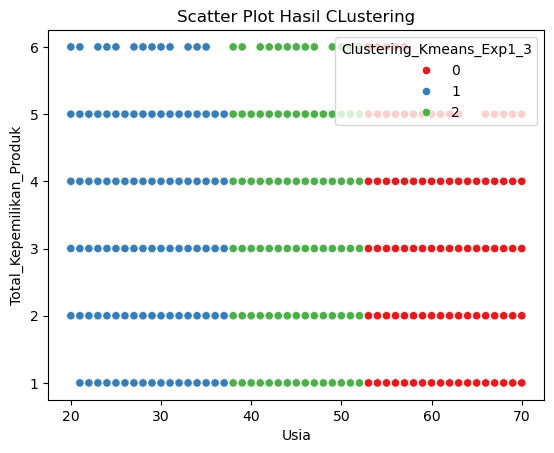

In [57]:
sns.scatterplot(data=data0, x='Usia', y='Total_Kepemilikan_Produk', hue='Clustering_Kmeans_Exp1_3', palette='Set1')
plt.title('Scatter Plot Hasil CLustering')
plt.show()

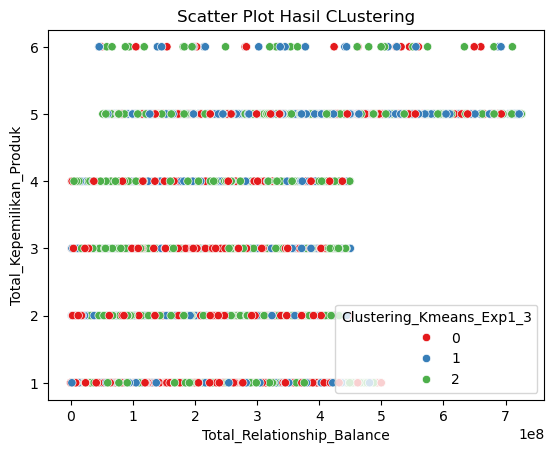

In [58]:
sns.scatterplot(data=data0, x='Total_Relationship_Balance', y='Total_Kepemilikan_Produk', hue='Clustering_Kmeans_Exp1_3', palette='Set1')
plt.title('Scatter Plot Hasil CLustering')
plt.show()

In [59]:
cluster_means = data[['Usia', 'Jumlah_Anak', 'Produk_Tabungan', 'Produk_Deposito', 'Produk_Kartu_Kredit', 'Produk_Kredit_Rumah', 'Produk_Kredit_Kendaraan', 'Produk_Kredit_Dana_Tunai', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']]
print(cluster_means)
pd

       Usia  Jumlah_Anak  Produk_Tabungan  Produk_Deposito  \
0      69.0            3                1                0   
1      23.0            0                1                0   
2      30.0            0                1                0   
3      45.0            0                1                0   
4      34.0            0                1                0   
...     ...          ...              ...              ...   
28121  41.0            0                1                1   
28122  28.0            0                1                1   
28123  52.0            0                1                1   
28124  47.0            0                1                1   
28126  58.0            4                1                1   

       Produk_Kartu_Kredit  Produk_Kredit_Rumah  Produk_Kredit_Kendaraan  \
0                        0                    0                        0   
1                        0                    0                        0   
2                        0 

<module 'pandas' from 'c:\\Users\\Josua\\anaconda3\\Lib\\site-packages\\pandas\\__init__.py'>

Group 0

In [60]:
data0[data0['Clustering_Kmeans_Exp1_3']==0][['Usia', 'Jumlah_Anak', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']].describe(include='all')

,Usia,Jumlah_Anak,Total_Kepemilikan_Produk,Total_Relationship_Balance
count,2132.000000,2132.000000,2132.000000,2.132000e+03
mean,58.840056,1.474672,2.930113,2.389776e+08
std,5.133619,1.467245,1.041285,1.379077e+08
min,53.000000,0.000000,1.000000,1.028000e+03
25%,55.000000,0.000000,2.000000,1.266333e+08
50%,57.000000,1.000000,3.000000,2.328763e+08
75%,62.000000,3.000000,4.000000,3.493216e+08
max,70.000000,4.000000,6.000000,7.181097e+08


In [61]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Area'].value_counts(normalize=True)

Area
Jakarta     0.478893
Bandung     0.166041
Solo        0.128987
Surabaya    0.126173
Jogja       0.072702
Bogor       0.027205
Name: proportion, dtype: float64

In [62]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Vintage'].value_counts(normalize=True)

Vintage
2 - 3 Tahun    0.486867
< 1 Tahun      0.313321
> 4 Tahun      0.199812
Name: proportion, dtype: float64

In [63]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Pendidikan'].value_counts(normalize=True)

Pendidikan
Sarjana                 0.258443
SD                      0.204972
SMA                     0.180113
Tidak Sekolah Formal    0.101313
Magister                0.088180
SMP                     0.083959
Doktor                  0.083021
Name: proportion, dtype: float64

In [64]:
data0[data0['Clustering_Kmeans_Exp1_3']==0]['Jenis_Kelamin'].value_counts(normalize=True)

Jenis_Kelamin
Laki-laki    0.668386
Perempuan    0.331614
Name: proportion, dtype: float64

Group 1

In [65]:
data0[data0['Clustering_Kmeans_Exp1_3']==1][['Usia', 'Jumlah_Anak', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']].describe(include='all')

,Usia,Jumlah_Anak,Total_Kepemilikan_Produk,Total_Relationship_Balance
count,3305.000000,3305.000000,3305.000000,3.305000e+03
mean,29.503177,1.191528,3.243873,2.439352e+08
std,4.254972,1.480683,1.008655,1.452356e+08
min,20.000000,0.000000,1.000000,1.016565e+06
25%,26.000000,0.000000,3.000000,1.222784e+08
50%,30.000000,0.000000,3.000000,2.408255e+08
75%,33.000000,2.000000,4.000000,3.578412e+08
max,37.000000,4.000000,6.000000,7.228870e+08


In [66]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Area'].value_counts(normalize=True)

Area
Jakarta     0.476248
Bandung     0.179728
Surabaya    0.126475
Solo        0.118306
Jogja       0.073222
Bogor       0.026021
Name: proportion, dtype: float64

In [67]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Vintage'].value_counts(normalize=True)

Vintage
2 - 3 Tahun    0.501967
< 1 Tahun      0.293192
> 4 Tahun      0.204841
Name: proportion, dtype: float64

In [68]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Pendidikan'].value_counts(normalize=True)

Pendidikan
Sarjana                 0.274130
SMA                     0.192436
SD                      0.180333
Doktor                  0.097731
Magister                0.087443
SMP                     0.084720
Tidak Sekolah Formal    0.083207
Name: proportion, dtype: float64

In [69]:
data0[data0['Clustering_Kmeans_Exp1_3']==1]['Jenis_Kelamin'].value_counts(normalize=True)

Jenis_Kelamin
Laki-laki    0.640847
Perempuan    0.359153
Name: proportion, dtype: float64

Group 2

In [70]:
data0[data0['Clustering_Kmeans_Exp1_3']==2][['Usia', 'Jumlah_Anak', 'Total_Kepemilikan_Produk', 'Total_Relationship_Balance']].describe(include='all')

,Usia,Jumlah_Anak,Total_Kepemilikan_Produk,Total_Relationship_Balance
count,3216.000000,3216.000000,3216.000000,3.216000e+03
mean,45.571206,1.310945,3.157960,2.377450e+08
std,4.278838,1.482616,1.045431,1.437032e+08
min,38.000000,0.000000,1.000000,1.384147e+06
25%,42.000000,0.000000,2.000000,1.166975e+08
50%,46.000000,1.000000,3.000000,2.309003e+08
75%,50.000000,3.000000,4.000000,3.468400e+08
max,52.000000,4.000000,6.000000,7.259942e+08


In [71]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Area'].value_counts(normalize=True)

Area
Jakarta     0.484142
Bandung     0.161692
Surabaya    0.131530
Solo        0.112562
Jogja       0.081468
Bogor       0.028607
Name: proportion, dtype: float64

In [72]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Vintage'].value_counts(normalize=True)

Vintage
2 - 3 Tahun    0.503731
< 1 Tahun      0.295398
> 4 Tahun      0.200871
Name: proportion, dtype: float64

In [73]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Pendidikan'].value_counts(normalize=True)

Pendidikan
Sarjana                 0.273321
SD                      0.181592
SMA                     0.180037
SMP                     0.095771
Doktor                  0.093905
Tidak Sekolah Formal    0.089552
Magister                0.085821
Name: proportion, dtype: float64

In [74]:
data0[data0['Clustering_Kmeans_Exp1_3']==2]['Jenis_Kelamin'].value_counts(normalize=True)

Jenis_Kelamin
Laki-laki    0.678483
Perempuan    0.321517
Name: proportion, dtype: float64

### Kesimpulan

Dari hasil clustering, yang menjadi pembeda adalah usia. Namun, bila hanya dari segi usia kita belum bisa melakukan segmentasi nasabah dengan baik (dilihat dari silhouette score yang masih belum mencapai 0.7). Hal yang dapat dilakukan ke depannya adalah dengan memperbanyak variabel dan melakukan iterasi lebih banyak.